In [204]:
import pandas as pd
import numpy as np
import os

In [3]:
cwd = os.getcwd()
cwd

'/Users/ivantanev/anaconda_projects/6e18bb67-29d5-4cfb-b290-4c7ef268d06a'

In [5]:
os.chdir("/Users/ivantanev/Desktop/SMARTDIE")

In [208]:
roll_0010_df = pd.read_csv("/Users/ivantanev/Desktop/SMARTDIE/raw_rolls/roll_0010.csv")

## Analysis of a singular roll (roll_id = 10)

In [209]:
roll_0010_df.shape

(136, 7)

In [210]:
roll_0010_df["a_abs"] = np.sqrt(roll_0010_df["ax"]**2 + roll_0010_df["ay"]**2 + roll_0010_df["az"]**2)
roll_0010_df["w_abs"] = np.sqrt(roll_0010_df["wx"]**2 + roll_0010_df["wy"]**2 + roll_0010_df["wz"]**2)
roll_0010_df

,time_ms,ax,ay,az,wx,wy,wz,a_abs,w_abs
0,0,-0.231,-0.564,-0.712,5.1,-52.0,-101.7,0.937230,114.336783
1,24,0.016,-0.116,-1.031,-8.5,-61.3,-88.7,1.037629,108.155582
2,44,-0.018,-0.133,-0.950,22.2,-7.6,-120.0,0.959434,122.272646
3,64,0.090,-0.141,-0.961,17.2,-7.5,-88.6,0.975450,90.565170
4,85,0.081,-0.116,-0.970,13.5,2.5,-59.5,0.980264,61.063492
...,...,...,...,...,...,...,...,...,...
131,2705,0.965,0.096,0.239,0.7,-2.3,0.2,0.998780,2.412468
132,2725,0.965,0.094,0.245,0.7,-3.1,0.0,1.000043,3.178050
133,2747,0.965,0.095,0.243,0.7,-2.4,0.3,0.999649,2.517936
134,2767,0.963,0.094,0.244,0.8,-3.2,0.0,0.997868,3.298485


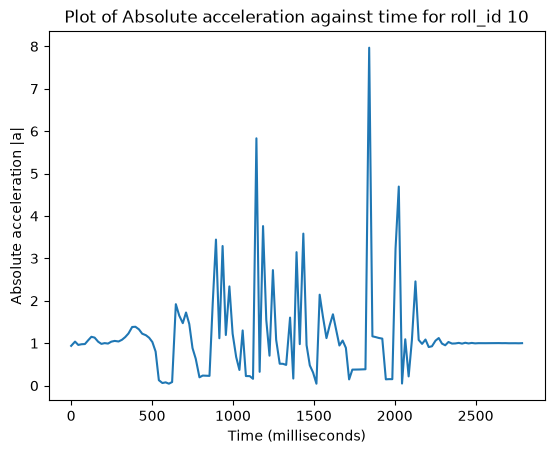

In [211]:
import matplotlib.pyplot as plt
plt.plot(roll_0010_df["time_ms"],
         roll_0010_df["a_abs"])
plt.xlabel("Time (milliseconds)")
plt.ylabel("Absolute acceleration |a|")
plt.title("Plot of Absolute acceleration against time for roll_id 10")
plt.show()

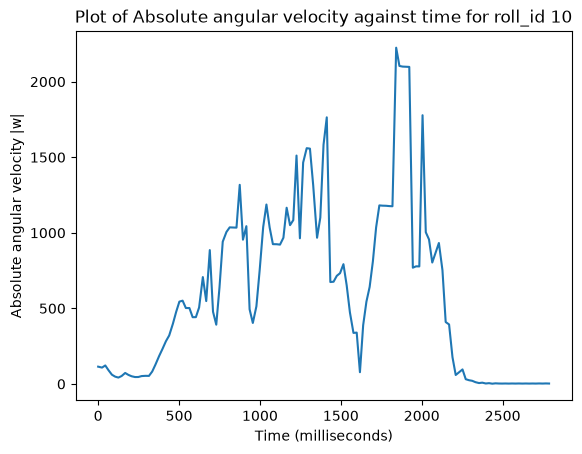

In [212]:
plt.plot(roll_0010_df["time_ms"],
         roll_0010_df["w_abs"])
plt.xlabel("Time (milliseconds)")
plt.ylabel("Absolute angular velocity |w|")
plt.title("Plot of Absolute angular velocity against time for roll_id 10")
plt.show()

## load_roll function and testing

In [213]:
from pathlib import Path
RAW_DATA_DIR = Path.home() / "Desktop" / "SMARTDIE" / "raw_rolls"
METADATA_DIR = Path.home() / "Desktop" / "SMARTDIE" / "metadata.csv"

def get_roll_file(roll_id):
    """This function takes in a roll_id and returns the file location in the raw_rolls folder if it exists."""
    path = RAW_DATA_DIR / f"roll_{roll_id:04d}.csv"
    if path.exists():
        return path
    else:
        raise FileNotFoundError(f"Roll {roll_id} does not exist")

In [214]:
get_roll_file(1000)

PosixPath('/Users/ivantanev/Desktop/SMARTDIE/raw_rolls/roll_1000.csv')

In [215]:
def load_roll(roll_id):
    """This function takes in a roll_id and return a pandas dataframe of the motion data"""
    roll_path = get_roll_file(roll_id)
    df = pd.read_csv(roll_path)
    df["a_abs"] = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)
    df["w_abs"] = np.sqrt(df["wx"]**2 + df["wy"]**2 + df["wz"]**2)
    return df

In [216]:
load_roll(2)

,time_ms,ax,ay,az,wx,wy,wz,a_abs,w_abs
0,0,-1.014,-0.537,-0.090,136.6,-24.9,51.2,1.150941,147.989898
1,22,-1.056,-0.382,-0.132,308.1,-16.0,-26.6,1.130701,309.659765
2,42,-1.032,0.044,-0.086,360.7,6.9,-0.5,1.036511,360.766337
3,63,-0.882,0.528,-0.162,94.3,-34.4,87.7,1.040650,133.293436
4,83,-1.599,0.387,-0.130,-38.0,70.0,189.4,1.650294,205.466202
...,...,...,...,...,...,...,...,...,...
483,9930,-0.904,0.477,-0.113,-1.8,7.9,-2.8,1.028355,8.572631
484,9950,-0.907,0.448,-0.126,-1.1,-0.4,-10.4,1.019426,10.465658
485,9970,-0.903,0.480,-0.141,1.2,1.6,-14.2,1.032323,14.340153
486,9992,-0.861,0.478,-0.169,18.4,18.9,-18.0,0.999183,31.933838


## Estimating T_s (start of stationary near end of roll)

In [217]:
roll_0003_df = load_roll(3)
roll_0003_df["w_abs"] = np.sqrt(roll_0003_df["wx"]**2 + roll_0003_df["wy"]**2 + roll_0003_df["wz"]**2)

In [218]:
def detect_stationary_start(df, threshold = 10, confirmation_ms = 400):
    """This function is given the motion dataset of a roll and returns an estimate T_s
    for beginning of stationarity at the end of the roll."""
    times = df["time_ms"]
    omega = df["w_abs"]
    
    for i in range(len(df)):
        if omega[i] > threshold:
            continue
            
        else:
            target_time = times[i] + confirmation_ms
            j = np.searchsorted(times, target_time)
            if j >= len(df):
                continue
            if np.all(omega[i: j + 1] < threshold):
                return times[i]
                
    return None

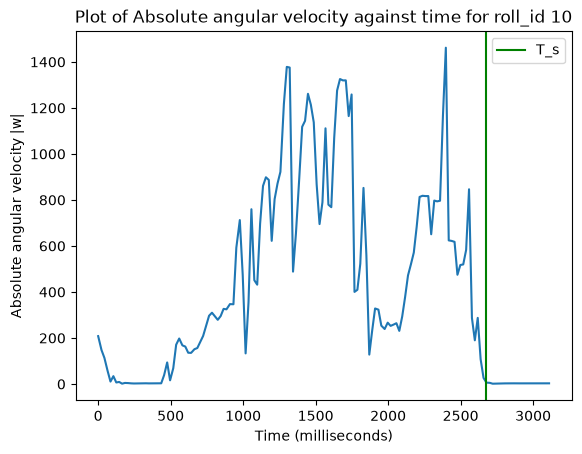

In [219]:
plt.plot(roll_0003_df["time_ms"],
         roll_0003_df["w_abs"])
plt.xlabel("Time (milliseconds)")
plt.ylabel("Absolute angular velocity |w|")
plt.title("Plot of Absolute angular velocity against time for roll_id 10")
T_s_roll_0003 = detect_stationary_start(roll_0003_df)
plt.axvline(T_s_roll_0003, color = "green", label = 'T_s')
plt.legend()
plt.show()

## Uploading Metadata and filtering eligible rolls

In [220]:
metadata = pd.read_csv(METADATA_DIR)
metadata

,roll_id,final_face,n_samples
0,1,3,107
1,2,1,488
2,3,2,153
3,4,2,137
4,5,4,91
...,...,...,...
995,996,5,82
996,997,2,128
997,998,6,139
998,999,3,91


In [221]:
table_list = []
for roll_id in range(1,1001):
    df = load_roll(roll_id)
    T_s = detect_stationary_start(df)
    times = df["time_ms"]
    
    roll_dic = {
            "roll_id" : roll_id,
            "eligible" : True,
            "reason" : "ok"
        }
    
    if T_s == None:
        roll_dic["eligible"] = False
        roll_dic["reason"] = "no stationary time found"
        table_list.append(roll_dic)
        continue

    if T_s - times[0] < 300:
        roll_dic["eligible"] = False
        roll_dic["reason"] = "not enough data"
        table_list.append(roll_dic)
        continue
    
    table_list.append(roll_dic)

            
table = pd.DataFrame(table_list)

In [222]:
table

,roll_id,eligible,reason
0,1,True,ok
1,2,False,no stationary time found
2,3,True,ok
3,4,True,ok
4,5,True,ok
...,...,...,...
995,996,True,ok
996,997,True,ok
997,998,True,ok
998,999,True,ok


In [223]:
table["eligible"].value_counts()

eligible
True     970
False     30
Name: count, dtype: int64

In [224]:
table["reason"].value_counts()

reason
ok                          970
no stationary time found     27
not enough data               3
Name: count, dtype: int64

In [225]:
eligible_rolls_df = table[table["eligible"]]
eligible_rolls_ids = eligible_rolls_df["roll_id"]
eligible_rolls_ids

0         1
2         3
3         4
4         5
5         6
       ... 
995     996
996     997
997     998
998     999
999    1000
Name: roll_id, Length: 970, dtype: int64

## Prediction Windows and Interpolation

In [226]:
def extract_prediction_window(df, L_ms, delta_ms, n_points):
    """This function takes in a dataset of a roll's motion, length of window, how early we want the prediction,
    and how many points we want in the window, and gives us back the window using interpolation"""
    times = df["time_ms"]
    T_s = detect_stationary_start(df)
    start_window = T_s - delta_ms - L_ms
    end_window = T_s - delta_ms
    causal_mask = times <= end_window
    causal_times = times[causal_mask]
    
    if start_window < times.iloc[0]:
        return None
    
    new_times = np.linspace(start_window, end_window, n_points)
    
    ax_new = np.interp(
        new_times,
        causal_times,
        df["ax"][causal_mask]
    )
    
    ay_new = np.interp(
        new_times,
        causal_times,
        df["ay"][causal_mask]
    )
    
    az_new = np.interp(
        new_times,
        causal_times,
        df["az"][causal_mask]
    )
    
    wx_new = np.interp(
        new_times,
        causal_times,
        df["wx"][causal_mask]
    )
    
    wy_new = np.interp(
        new_times,
        causal_times,
        df["wy"][causal_mask]
    )
    
    wz_new = np.interp(
        new_times,
        causal_times,
        df["wz"][causal_mask]
    )
    X = np.column_stack([
        ax_new,
        ay_new,
        az_new,
        wx_new,
        wy_new,
        wz_new
    ])

    new_df = pd.DataFrame(
        X,
        columns=["ax", "ay", "az", "wx", "wy", "wz"]
    )
    return new_df


In [227]:
extract_prediction_window(roll_0003_df, 300, 200, 100)

,ax,ay,az,wx,wy,wz
0,0.327250,0.474600,-0.665450,358.630000,363.180000,268.290000
1,0.340129,0.461267,-0.645602,376.599697,367.664848,274.017273
2,0.353008,0.447933,-0.625753,394.569394,372.149697,279.744545
3,0.365886,0.434600,-0.605905,412.539091,376.634545,285.471818
4,0.378765,0.421267,-0.586056,430.508788,381.119394,291.199091
...,...,...,...,...,...,...
95,0.091152,-0.065242,0.107515,403.963636,-149.696970,307.109091
96,0.077364,-0.049182,0.084636,405.872727,-168.772727,247.881818
97,0.063576,-0.033121,0.061758,407.781818,-187.848485,188.654545
98,0.049788,-0.017061,0.038879,409.690909,-206.924242,129.427273


## Train/Validation/Test split and StandardScaler

In [228]:
from sklearn.model_selection import train_test_split

In [229]:
eligible_metadata = metadata[
    metadata["roll_id"].isin(eligible_rolls_ids)
]
eligible_metadata.drop(columns = ["n_samples"])

,roll_id,final_face
0,1,3
2,3,2
3,4,2
4,5,4
5,6,6
...,...,...
995,996,5
996,997,2
997,998,6
998,999,3


In [ ]:
train, temp = train_test_split(
    eligible_metadata,
    test_size = 0.3,
    stratify = eligible_metadata["final_face"],
    random_state = 42
)

In [231]:
validation, test = train_test_split(
    temp,
    test_size = 0.5,
    stratify = temp["final_face"],
    random_state = 42
)

In [232]:
train["final_face"].value_counts(normalize=True)

final_face
5    0.225331
2    0.182622
4    0.166421
3    0.156112
6    0.148748
1    0.120766
Name: proportion, dtype: float64

In [233]:
validation["final_face"].value_counts(normalize=True)

final_face
5    0.220690
2    0.186207
4    0.165517
6    0.151724
3    0.151724
1    0.124138
Name: proportion, dtype: float64

In [234]:
test["final_face"].value_counts(normalize=True)

final_face
5    0.226027
2    0.184932
4    0.171233
3    0.157534
6    0.143836
1    0.116438
Name: proportion, dtype: float64

In [ ]:
X_train = []
y_train = []

for _, row in train.iterrows():
    roll_id = row["roll_id"]
    final_face = row["final_face"]
    df = load_roll(roll_id)

    window = extract_prediction_window(
        df,
        L_ms = 400,
        delta_ms = 100,
        n_points = 20
    )

    flat_window = window.to_numpy().flatten()

    X_train.append(flat_window)
    y_train.append(final_face)

X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
print(X_train.shape)
print(y_train.shape)

In [ ]:
X_validate = []
y_validate = []

for _, row in validation.iterrows():
    roll_id = row["roll_id"]
    final_face = row["final_face"]
    df = load_roll(roll_id)

    window = extract_prediction_window(
        df,
        L_ms = 400,
        delta_ms = 100,
        n_points = 20
    )

    flat_window = window.to_numpy().flatten()

    X_validate.append(flat_window)
    y_validate.append(final_face)

X_validate = np.array(X_validate)
y_validate = np.array(y_validate)

In [ ]:
print(X_validate.shape)
print(y_validate.shape)

In [ ]:
X_test = []
y_test = []

for _, row in test.iterrows():
    roll_id = row["roll_id"]
    final_face = row["final_face"]
    df = load_roll(roll_id)

    window = extract_prediction_window(
        df,
        L_ms = 400,
        delta_ms = 100,
        n_points = 20
    )

    flat_window = window.to_numpy().flatten()

    X_test.append(flat_window)
    y_test.append(final_face)

X_test = np.array(X_test)
y_test = np.array(y_test)

In [ ]:
def build_prediction_dataset(split, L_ms, delta_ms, n_points):
    """
    This function takes in the split we are interested in along with window size and delta and returns the split in a format ready 
    for fitting a model.
    """
    X = []
    y = []
    
    for _, row in split.iterrows():
        roll_id = row["roll_id"]
        final_face = row["final_face"]
        df = load_roll(roll_id)
    
        window = extract_prediction_window(
            df,
            L_ms,
            delta_ms,
            n_points
        )
        
        if window is None:
            continue
            
        flat_window = window.to_numpy().flatten()
    
        X.append(flat_window)
        y.append(final_face)

    X = np.array(X)
    y = np.array(y)
    return X, y

In [ ]:
print(X_test.shape)
print(y_test.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_validate_scaled = scaler.transform(X_validate)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

## Multinomial Logistic Regression (Final Face Prediction)

In [302]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter = 2000
)


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_validate, y_pred)
print(accuracy)

In [ ]:
validation_accuracies = []
C_values = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
for C in C_values:
    model = LogisticRegression(
        C = C,
        max_iter = 2000
    )
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_validate_scaled)
    accuracy = accuracy_score(y_validate, y_pred)
    validation_accuracies.append(accuracy)
    print(C, accuracy)

In [260]:
delta_values = np.arange(50, 501, 5)
validation_accuracies = []
## Quick plot to evaluate what accuracy looks like on the evaluation set with fixed C = 0.02 for all models
for delta in delta_values:
    X_train, y_train = build_prediction_dataset(train, 400, delta, 20)
    X_validate, y_validate = build_prediction_dataset(validation, 400, delta, 20)
    X_train_scaled = scaler.fit_transform(X_train)
    X_validate_scaled = scaler.transform(X_validate)
    
    model = LogisticRegression(
        C = 0.02,
        max_iter = 2000
    )
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_validate_scaled)
    
    accuracy = accuracy_score(y_validate, y_pred)
    validation_accuracies.append(accuracy)

In [ ]:
values, frequencies = np.unique(
    train["final_face"],
    return_counts=True
)

majority_face = values[np.argmax(frequencies)]
majority_accuracy = np.max(frequencies) / np.sum(frequencies)

print("Majority face:", majority_face)
print("Majority baseline:", majority_accuracy)
plt.plot(delta_values, validation_accuracies)
plt.axhline(majority_accuracy)
plt.gca().invert_xaxis()
plt.show()

## Quadratic Discriminant Analysis (Final Face Prediction)

In [240]:
X_train, y_train = build_prediction_dataset(train, 400, 100, 20)
X_validate, y_validate = build_prediction_dataset(validation, 400, 100, 20)

In [241]:
X_train_scaled = scaler.fit_transform(X_train)
X_validate_scaled = scaler.transform(X_validate)

In [246]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model = QuadraticDiscriminantAnalysis(
    solver = "eigen",
    shrinkage = 0.1
)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_validate_scaled)
accuracy = accuracy_score(y_validate, y_pred)

In [247]:
print(accuracy)

0.6137931034482759


In [249]:
shrinkage_values = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1]
for shrinkage in shrinkage_values:
    model = QuadraticDiscriminantAnalysis(
        solver = "eigen",
        shrinkage = shrinkage
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_validate_scaled)
    accuracy = accuracy_score(y_validate, y_pred)
    print(shrinkage, accuracy)

0.01 0.4413793103448276
0.05 0.5655172413793104
0.1 0.6137931034482759
0.2 0.6482758620689655
0.5 0.6827586206896552
0.8 0.6551724137931034
1 0.6344827586206897


In [255]:
delta_values = np.arange(50,501, 5)
validation_accuracies_qda = []
for delta in delta_values:
    X_train, y_train = build_prediction_dataset(train, 400, delta, 20)
    X_validate, y_validate = build_prediction_dataset(validation, 400, delta, 20)
    X_train_scaled = scaler.fit_transform(X_train)
    X_validate_scaled = scaler.transform(X_validate)
    
    model = QuadraticDiscriminantAnalysis(
        solver = "eigen",
        shrinkage = 0.5
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_validate_scaled)
    accuracy = accuracy_score(y_validate, y_pred)
    validation_accuracies_qda.append(accuracy)

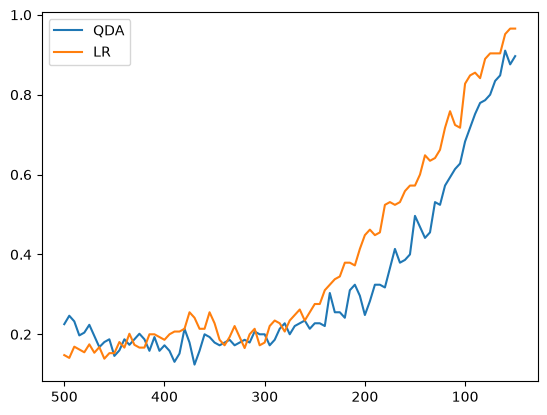

In [261]:
plt.plot(delta_values, validation_accuracies_qda, label = "QDA")
plt.plot(delta_values, validation_accuracies, label = "LR")
plt.gca().invert_xaxis()
plt.legend()
plt.show()

## Decision Tree (Final Face Prediction)

In [262]:
from sklearn.tree import DecisionTreeClassifier
X_train, y_train = build_prediction_dataset(train, 400, 100, 20)
X_validate, y_validate = build_prediction_dataset(validation, 400, 100, 20)
model = DecisionTreeClassifier(
    max_depth = 3
)
model.fit(X_train, y_train)
y_pred = model.predict(X_validate)
accuracy = accuracy_score(y_validate, y_pred)
print(accuracy)

0.5310344827586206


In [263]:
y_pred_train = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_pred_train)

print("Training:", train_accuracy)
print("Validation:", accuracy)

Training: 0.6100443131462334
Validation: 0.5310344827586206


In [264]:
depth_values = [2, 3, 4, 5, 6, 8, 10, 15, 20, None]
for depth in depth_values:
    X_train, y_train = build_prediction_dataset(train, 400, 100, 20)
    X_validate, y_validate = build_prediction_dataset(validation, 400, 100, 20)
    
    model = DecisionTreeClassifier(
        max_depth = depth,
        random_state = 42
    )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_validate)
    accuracy_t = accuracy_score(y_train, y_pred_train)
    accuracy_v = accuracy_score(y_validate, y_pred_val)
    print(depth, accuracy_t, accuracy_v)

2 0.5007385524372231 0.46206896551724136
3 0.6100443131462334 0.5310344827586206
4 0.7223042836041359 0.6413793103448275
5 0.8330871491875923 0.6758620689655173
6 0.880354505169867 0.6758620689655173
8 0.9438700147710487 0.6758620689655173
10 0.982274741506647 0.7034482758620689
15 1.0 0.7241379310344828
20 1.0 0.7241379310344828
None 1.0 0.7241379310344828


In [268]:
min_leaf_values = [1, 2, 5, 10, 20, 30]
for min_leaf_val in min_leaf_values:
    X_train, y_train = build_prediction_dataset(train, 400, 100, 20)
    X_validate, y_validate = build_prediction_dataset(validation, 400, 100, 20)
    
    model = DecisionTreeClassifier(
        max_depth = 15,
        random_state = 42,
        min_samples_leaf = min_leaf_val
    )
    
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_validate)
    accuracy_t = accuracy_score(y_train, y_pred_train)
    accuracy_v = accuracy_score(y_validate, y_pred_val)
    print(min_leaf_val, accuracy_t, accuracy_v)

1 1.0 0.7241379310344828
2 0.9630723781388478 0.6758620689655173
5 0.8995568685376661 0.7103448275862069
10 0.8493353028064993 0.7034482758620689
20 0.7961595273264401 0.7034482758620689
30 0.7621861152141802 0.6689655172413793


In [269]:
delta_values = np.arange(50,501, 5)
validation_accuracies_tree = []
for delta in delta_values:
    X_train, y_train = build_prediction_dataset(train, 400, delta, 20)
    X_validate, y_validate = build_prediction_dataset(validation, 400, delta, 20)
    
    model = DecisionTreeClassifier(
        max_depth = 15,
        random_state = 42,
        min_samples_leaf = 10
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_validate)
    accuracy = accuracy_score(y_validate, y_pred)
    validation_accuracies_tree.append(accuracy)

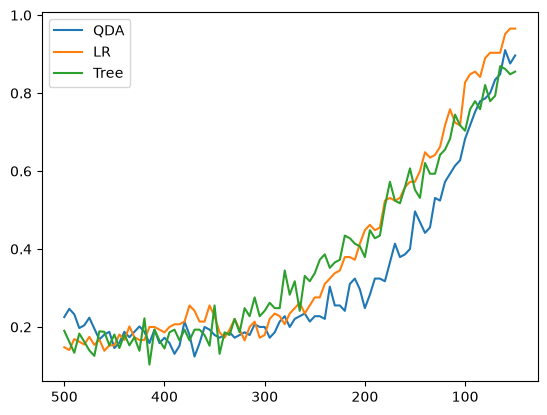

In [270]:
plt.plot(delta_values, validation_accuracies_qda, label = "QDA")
plt.plot(delta_values, validation_accuracies, label = "LR")
plt.plot(delta_values, validation_accuracies_tree, label = "Tree")
plt.gca().invert_xaxis()
plt.legend()
plt.show()

## Instantenous acceleration predictor (Final Face Prediction)

In [288]:
def get_instantaneous_acceleration(df, delta_ms):
    """
    This function gets the instantenous acceleration of our dice delta_ms seconds before stationarity.
    """
    T_s = detect_stationary_start(df)
    
    if T_s is None:
        return None
        
    t_p = T_s - delta_ms

    times = df["time_ms"]
    mask = times <= t_p

    if not mask.any():
        return None

    masked_times = times[mask]

    ax = np.interp(t_p, masked_times, df["ax"][mask])
    ay = np.interp(t_p, masked_times, df["ay"][mask])
    az = np.interp(t_p, masked_times, df["az"][mask])

    return ax, ay, az

In [289]:
def face_from_acceleration(ax, ay, az):
    values = {
        6: ax,
        1: -ax,    
        3: ay,     
        4: -ay,    
        2: az,     
        5: -az     
    }

    return max(values, key=values.get)

In [293]:
validation_accuracies_acc = []
for delta in delta_values:
    y_true = []
    y_pred = []

    for _, row in validation.iterrows():
        roll_id = row["roll_id"]
        final_face = row["final_face"]

        df = load_roll(roll_id)
        ax, ay, az = get_instantaneous_acceleration(df, delta)
        y_prediction = face_from_acceleration(ax, ay, az)
        y_true.append(final_face)
        y_pred.append(y_prediction)
    accuracy = accuracy_score(y_true, y_pred)
    validation_accuracies_acc.append(accuracy)

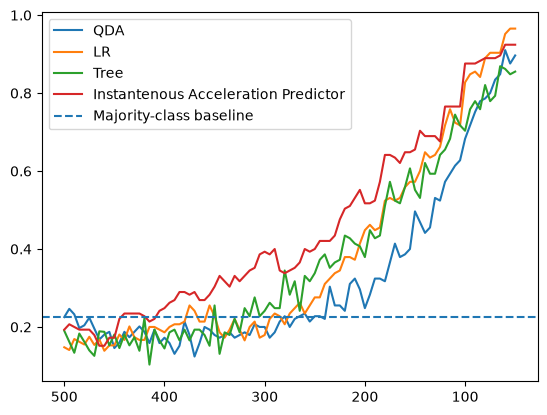

In [297]:
plt.plot(delta_values, validation_accuracies_qda, label = "QDA")
plt.plot(delta_values, validation_accuracies, label = "LR")
plt.plot(delta_values, validation_accuracies_tree, label = "Tree")
plt.plot(delta_values, validation_accuracies_acc, label = "Instantenous Acceleration Predictor")
values, frequencies = np.unique(
    train["final_face"],
    return_counts=True
)
majority_face = values[np.argmax(frequencies)]
majority_accuracy = np.max(frequencies) / np.sum(frequencies)
plt.axhline(
    majority_accuracy,
    linestyle="--",
    label="Majority-class baseline"
)
plt.gca().invert_xaxis()
plt.legend()
plt.show()


## Final Face Prediction Comparison Plot

In [298]:
train_final = pd.concat(
    [train, validation],
    ignore_index = True
)
print(len(train_final))

824


In [299]:
print(len(test))

146


In [306]:
delta_values = np.arange(50, 501, 5)
test_accuracies_lr = []
test_accuracies_qda = []
test_accuracies_dtree = []
test_accuracies_acc = []
scaler = StandardScaler()

for delta in delta_values:
    X_train, y_train = build_prediction_dataset(train_final, 400, delta, 20)
    X_test, y_test = build_prediction_dataset(test, 400, delta, 20)

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #Firstly Logistic Regression
    lr = LogisticRegression(
        max_iter = 2000,
        C = 0.02
    )
    
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    test_accuracies_lr.append(accuracy_score(y_test, y_pred_lr))

    #Secondly QDA
    qda = QuadraticDiscriminantAnalysis(
        solver = "eigen",
        shrinkage = 0.5
    )
    qda.fit(X_train_scaled, y_train)
    y_pred_qda = qda.predict(X_test_scaled)
    test_accuracies_qda.append(accuracy_score(y_test, y_pred_qda))

    #Thirdly Decision tree
    tree = DecisionTreeClassifier(
        max_depth = 15,
        min_samples_leaf = 10,
        random_state = 42
    )

    tree.fit(X_train, y_train)
    y_pred_tree = tree.predict(X_test)
    test_accuracies_dtree.append(accuracy_score(y_test, y_pred_tree))

In [307]:
for delta in delta_values:
    y_true = []
    y_pred = []

    for _, row in test.iterrows():
        roll_id = row["roll_id"]
        final_face = row["final_face"]

        df = load_roll(roll_id)
        ax, ay, az = get_instantaneous_acceleration(df, delta)
        y_prediction = face_from_acceleration(ax, ay, az)
        y_true.append(final_face)
        y_pred.append(y_prediction)
    accuracy = accuracy_score(y_true, y_pred)
    test_accuracies_acc.append(accuracy)

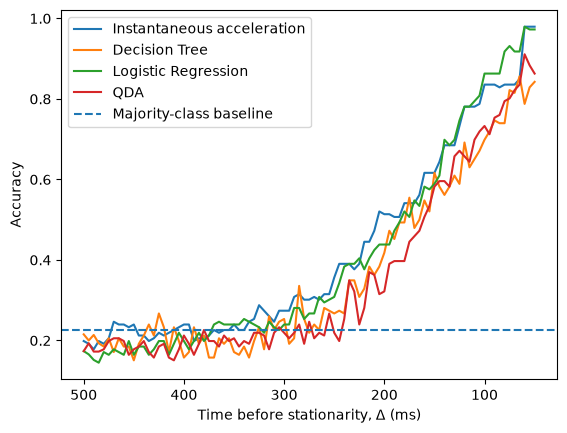

In [327]:
plt.plot(delta_values, test_accuracies_acc, label = "Instantaneous acceleration")
plt.plot(delta_values, test_accuracies_dtree, label = "Decision Tree")
plt.plot(delta_values, test_accuracies_lr, label = "Logistic Regression")
plt.plot(delta_values, test_accuracies_qda, label = "QDA")

majority_face = values[np.argmax(frequencies)]
majority_accuracy = np.max(frequencies) / np.sum(frequencies)

plt.axhline(
    majority_accuracy,
    linestyle="--",
    label="Majority-class baseline"
)
plt.legend(frameon=False)
plt.ylabel("Accuracy")
plt.xlabel("Time before stationarity, Δ (ms)")
plt.legend()
plt.gca().invert_xaxis()
plt.savefig(
    "final_face_prediction.png",
    bbox_inches="tight",
    transparent=True
)

## Self-Attention Neural Network (Temporal Reconstruction)

In [328]:
N_STATES = 15
WINDOW_MS = 300
TAU = np.linspace(0, 1, N_STATES)

In [340]:
def extract_reconstruction_states(df):
    """
    This function takes in a roll dataset and returns resampled 15 states of the last 300ms before stationarity.
    """
    T_s = detect_stationary_start(df)
    
    if T_s is None:
        return None

    start_time = T_s - WINDOW_MS

    if start_time < df["time_ms"].iloc[0]:
        return None

    target_times = np.linspace(start_time, T_s, N_STATES)
    
    states = np.column_stack([
        np.interp(target_times, df["time_ms"], df["ax"]),
        np.interp(target_times, df["time_ms"], df["ay"]),
        np.interp(target_times, df["time_ms"], df["az"]),
        np.interp(target_times, df["time_ms"], df["wx"]),
        np.interp(target_times, df["time_ms"], df["wy"]),
        np.interp(target_times, df["time_ms"], df["wz"]),
    ])
                  
    return states

In [342]:
def normalise_directions(states):
    """
    This function takes in 15 resampled states and gives back their acceleration and angular velocity components normalised
    """
    states = states.copy()
    a = states[:, :3]
    w = states[:, 3:]

    a_norm = np.linalg.norm(a, axis = 1, keepdims = True)
    w_norm = np.linalg.norm(w, axis = 1, keepdims = True)

    a_norm = np.maximum(a_norm, 1e-8)
    w_norm = np.maximum(w_norm, 1e-8)

    states[:, :3] = a / a_norm
    states[:, 3:] = w / w_norm

    return states

In [350]:
def build_reconstruction_dataset(split_df):
    X = []
    faces = []
    roll_ids = []
    
    for _, row in split_df.iterrows():
        roll_id = row["roll_id"]
        face = int(row["final_face"])
    
        df = load_roll(roll_id)
    
        states = extract_reconstruction_states(df)
    
        if states is None:
            continue
        states = normalise_directions(states)
    
        X.append(states)
        faces.append(face)
        roll_ids.append(roll_id)
    
    return (
        np.array(X, dtype = np.float32),
        np.array(faces, dtype = np.int32),
        np.array(roll_ids)
    )


In [352]:
X_train, F_train, train_ids = build_reconstruction_dataset(train_final)
X_test, F_test, test_ids = build_reconstruction_dataset(test)

In [353]:
print("Train:", X_train.shape, F_train.shape)
print("Test: ", X_test.shape, F_test.shape)

print("Total:", len(X_train) + len(X_test))

Train: (824, 15, 6) (824,)
Test:  (146, 15, 6) (146,)
Total: 970


In [355]:
indices = np.arange(len(X_train))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=F_train
)

X_tr = X_train[train_idx]
F_tr = F_train[train_idx]
X_val = X_train[val_idx]
F_val = F_train[val_idx]

In [356]:
print(X_tr.shape)
print(X_val.shape)
print(X_test.shape)

(700, 15, 6)
(124, 15, 6)
(146, 15, 6)


In [367]:
def shuffle_sequences(X, seed):
    rng = np.random.default_rng(seed)

    X_shuffled = np.empty_like(X)
    y = np.empty((len(X), 15, 1), dtype=np.float32)

    for r in range(len(X)):
        permutation = rng.permutation(15)

        X_shuffled[r] = X[r, permutation]
        y[r, :, 0] = TAU[permutation]

    return X_shuffled, y

In [368]:
X_tr_shuf, y_tr = shuffle_sequences(X_tr, seed=1)
X_val_shuf, y_val = shuffle_sequences(X_val, seed=2)
X_test_shuf, y_test = shuffle_sequences(X_test, seed=3)

In [369]:
print(X_tr_shuf.shape, y_tr.shape)
print(X_val_shuf.shape, y_val.shape)
print(X_test_shuf.shape, y_test.shape)

print(y_tr[0, :, 0])

(700, 15, 6) (700, 15, 1)
(124, 15, 6) (124, 15, 1)
(146, 15, 6) (146, 15, 1)
[0.07142857 0.85714287 0.5        0.71428573 1.         0.2857143
 0.35714287 0.5714286  0.         0.64285713 0.14285715 0.9285714
 0.78571427 0.42857143 0.21428572]


In [370]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [371]:
state_input = keras.Input(
    shape = (15,6),
    name = "states"
)
face_input = keras.Input(
    shape = (),
    dtype =  "int32",
    name = "face"
)

In [372]:
x = layers.Dense(32, name = "state_embedding")(state_input)

In [373]:
face_zero = layers.Lambda(
    lambda f : f - 1
)(face_input)

In [374]:
f = layers.Embedding(
    input_dim = 6,
    output_dim = 32,
    name = "face_embedding"
)(face_zero)

In [375]:
f = layers.RepeatVector(15)(f)

In [376]:
x = layers.Concatenate()([x, f])
x = layers.Dense(32, name = "combined_embedding")(x)

In [377]:
attn = layers.MultiHeadAttention(
    num_heads = 4,
    key_dim = 8,
    name = "self_attention"
)(x, x)

In [378]:
x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)

In [379]:
ff = layers.Dense(64, activation = "relu")(x)
ff = layers.Dense(32)(ff)

x = layers.Add()([x, ff])
x = layers.LayerNormalization()(x)

In [380]:
tau_hat = layers.Dense(
    1,
    activation = "sigmoid",
    name = "tau_hat"
)(x)

In [382]:
model = keras.Model(
    inputs = [state_input, face_input],
    outputs = tau_hat
)

In [383]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ face (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None)            │          0 │ face[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ states (InputLayer) │ (None, 15, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ face_embedding      │ (None, 32)        │        192 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_embedding     │ (None, 15, 32)    │        224 │ states[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 15, 32)    │          0 │ face_embedding[0… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 15, 64)    │          0 │ state_embedding[… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_embedding  │ (None, 15, 32)    │      2,080 │ concatenate[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 15, 32)    │      4,224 │ combined_embeddi… │
│ (MultiHeadAttentio… │                   │            │ combined_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 15, 32)    │          0 │ combined_embeddi… │
│                     │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 15, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 15, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 15, 32)    │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 15, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 15, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tau_hat (Dense)     │ (None, 15, 1)     │         33 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [384]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = "mse"
)

In [385]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [386]:
history = model.fit(
    [X_tr_shuf, F_tr],
    y_tr,
    validation_data = ([X_val_shuf, F_val], y_val),
    epochs = 200,
    batch_size = 32,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1065 - val_loss: 0.0815
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0779 - val_loss: 0.0745
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0710 - val_loss: 0.0693
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0647 - val_loss: 0.0638
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0581 - val_loss: 0.0562
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0518 - val_loss: 0.0520
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0471 - val_loss: 0.0469
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0444 - val_loss: 0.0455
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0424 - val_loss: 0.0440
Epoch 10/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0409 - val_loss: 0.0425
Epoch 11/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0395 - val_loss: 0.0423
Epoch 12/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

In [387]:
print("Epochs trained:", len(history.history["loss"]))
print("Best validation loss:", min(history.history["val_loss"]))

Epochs trained: 66
Best validation loss: 0.0359252393245697


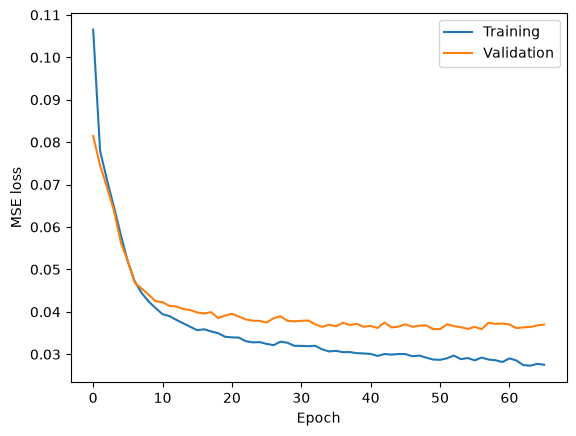

In [388]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.show()

In [389]:
y_pred = model.predict(
    [X_test_shuf, F_test],
    verbose=0
)

print(y_pred.shape)

(146, 15, 1)


In [390]:
from scipy.stats import spearmanr

spearman_scores = []

for r in range(len(y_test)):
    true_tau = y_test[r, :, 0]
    pred_tau = y_pred[r, :, 0]

    rho, _ = spearmanr(true_tau, pred_tau)
    spearman_scores.append(rho)

spearman_scores = np.array(spearman_scores)

print("Mean Spearman:", spearman_scores.mean())
print("Median Spearman:", np.median(spearman_scores))

Mean Spearman: 0.7819716242661446
Median Spearman: 0.8285714285714284


In [391]:
def pairwise_accuracy(true_tau, pred_tau):
    correct = 0
    total = 0
    for i in range(15):
        for j in range(i + 1, 15):

            true_order = true_tau[i] < true_tau[j]
            pred_order = pred_tau[i] < pred_tau[j]

            correct += (true_order == pred_order)
            total += 1

    return correct / total

In [392]:
pairwise_scores = []

for r in range(len(y_test)):
    score = pairwise_accuracy(
        y_test[r, :, 0],
        y_pred[r, :, 0]
    )
    pairwise_scores.append(score)

pairwise_scores = np.array(pairwise_scores)

print("Mean pairwise accuracy:", pairwise_scores.mean())
print("Median pairwise accuracy:", np.median(pairwise_scores))

Mean pairwise accuracy: 0.8175472928897586
Median pairwise accuracy: 0.8285714285714286


In [393]:
rng = np.random.default_rng(42)

n_boot = 10000
boot_pairwise = np.empty(n_boot)
boot_spearman = np.empty(n_boot)

for b in range(n_boot):
    idx = rng.choice(
        len(pairwise_scores),
        size=len(pairwise_scores),
        replace=True
    )

    boot_pairwise[b] = pairwise_scores[idx].mean()
    boot_spearman[b] = spearman_scores[idx].mean()

pairwise_ci = np.percentile(boot_pairwise, [2.5, 97.5])
spearman_ci = np.percentile(boot_spearman, [2.5, 97.5])

print("Pairwise mean:", pairwise_scores.mean())
print("95% CI:", pairwise_ci)

print("Spearman mean:", spearman_scores.mean())
print("95% CI:", spearman_ci)

Pairwise mean: 0.8175472928897586
95% CI: [0.80287019 0.83183301]
Spearman mean: 0.7819716242661446
95% CI: [0.75026908 0.81100844]


In [401]:
rng = np.random.default_rng(11)

r = rng.integers(len(X_test_shuf))

print("Test index:", r)
print("Roll ID:", test_ids[r])
print("Final face:", F_test[r])
print("Pairwise accuracy:", pairwise_scores[r])
print("Spearman:", spearman_scores[r])

Test index: 19
Roll ID: 857
Final face: 2
Pairwise accuracy: 0.8476190476190476
Spearman: 0.8785714285714284


In [402]:
true_tau = y_test[r, :, 0]
pred_tau = y_pred[r, :, 0]

In [403]:
true_labels = np.argsort(np.argsort(true_tau)) + 1
pred_labels = np.argsort(np.argsort(pred_tau)) + 1
print("True positions:")
print(true_labels)

print("Predicted positions:")
print(pred_labels)

True positions:
[ 4 15  2  8 11  6  1 14  7 10 13  5 12  9  3]
Predicted positions:
[ 4 15  5  8 11  2  6 13  9 10 14  3 12  7  1]


In [404]:
pred_order = np.argsort(pred_tau)
reconstructed_sequence = true_labels[pred_order]

print("Correct sequence:")
print(np.arange(1, 16))

print("Network reconstruction:")
print(reconstructed_sequence)

Correct sequence:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Network reconstruction:
[ 3  6  5  4  2  1  9  8  7 10 11 12 14 13 15]


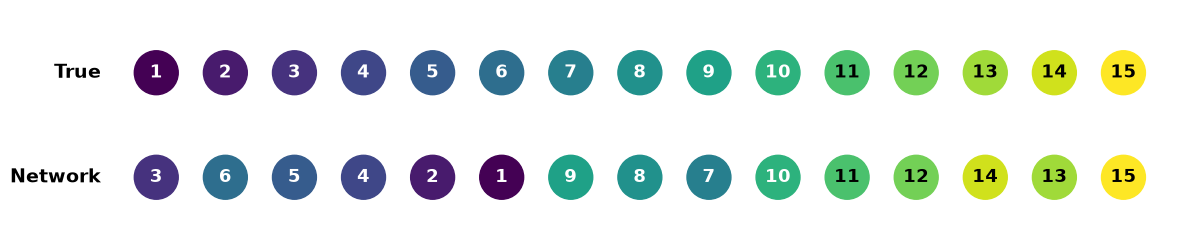

In [410]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

true_sequence = np.arange(1, 16)

pred_order = np.argsort(pred_tau)
reconstructed_sequence = true_labels[pred_order]
fig, ax = plt.subplots(figsize=(12, 2.6))

x = np.arange(1, 16)

cmap = plt.get_cmap("viridis")
norm = Normalize(vmin=1, vmax=15)


ax.scatter(
    x,
    np.ones(15),
    s=1000,
    c=true_sequence,
    cmap=cmap,
    norm=norm
)

ax.scatter(
    x,
    np.zeros(15),
    s=1000,
    c=reconstructed_sequence,
    cmap=cmap,
    norm=norm
)

def text_colour(state):
    r, g, b, _ = cmap(norm(state))


    brightness = 0.299*r + 0.587*g + 0.114*b

    if brightness < 0.55:
        return "white"
    else:
        return "black"



for j, state in enumerate(true_sequence):
    ax.text(
        x[j],
        1,
        str(state),
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=text_colour(state)
    )

for j, state in enumerate(reconstructed_sequence):
    ax.text(
        x[j],
        0,
        str(state),
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=text_colour(state)
    )

ax.text(
    0.2,
    1,
    "True",
    ha="right",
    va="center",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.2,
    0,
    "Network",
    ha="right",
    va="center",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlim(-0.5, 15.7)
ax.set_ylim(-0.6, 1.6)

ax.axis("off")

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.tight_layout()

fig.savefig(
    "roll_857_reconstruction.pdf",
    bbox_inches="tight",
    transparent=True
)


plt.show()

In [411]:
def consecutive_angles(vectors):
    dots = np.sum(vectors[:, :-1] * vectors[:, 1:], axis=2)
    dots = np.clip(dots, -1.0, 1.0)
    return np.degrees(np.arccos(dots))

acc_angles = consecutive_angles(X_test[:, :, :3])
gyro_angles = consecutive_angles(X_test[:, :, 3:])

print("Acceleration:")
print("Mean:", acc_angles.mean())
print("Median:", np.median(acc_angles))

print("\nAngular velocity:")
print("Mean:", gyro_angles.mean())
print("Median:", np.median(gyro_angles))

Acceleration:
Mean: 27.189121
Median: 17.29663

Angular velocity:
Mean: 53.865986
Median: 33.87497
